Vamos a usar algunas técnicas de template matching para poder encontrar el logo dado como template en la lista de imagenes. 

Algunas consideraciónes de template matching como método para dectar los logos:

* es invariante al desplazamiento
* no es invariante a escala
* no es invariante a rotación
* un template en escala de grises puede terminar detectando el fondo blanco en lugar de la forma

Luego de realizar el EDA sobre el dataset y el template observamos que:

* el logo se define por su forma
* la escala, el color, la perspectiva e iluminación varían
* el template tiene bordes suavizados
* el fondo blanco domina el template (borde muy grandes) y está presente en varias imágenes del dataset (el fondo blanco puede dominar la correlación en template matching)

Podriamos usar templateMatching de CV pero el problema que tenemos es que los mismos no están a la misma escala ni en la misma orientación, con lo cual, vamos a tener que usar algoritmos que no se vean afectados por la rotación y escalado de lo que queremos detectar. Ergo usaremos SHIFT/ORB, que en contraposición es:

* invariante a escala
* invariante a rotación
* robusto a cambios moderados de iluminación y perspectiva

In [1]:
##Se cargan las librerías necesarias
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

def buscar_carpeta(nombre="images"):
    """Busca una carpeta desde el directorio actual hacia arriba."""
    base = Path.cwd()
    for carpeta in [base]:
        candidata = carpeta / nombre
        if candidata.is_dir():
            return candidata
    raise FileNotFoundError(f"No se encontro la carpeta {nombre!r} desde {base}")


In [2]:
template_path = Path.cwd().resolve() / "template"
template_file = cv2.imread(str(template_path / "pattern.png"))

## Matching robusto con SIFT sobre bordes

Primero vamos a crear un método que nos permita hacer una detección de objetos, que no tenga problemas sobre la rotación o escalado de los objetos en la imagen con respecto al template. Para eso vamos a usar SIFT.

Detalle: Se usa Canny sobre el template y la imágen para evitar que la inversión rojo/blanco del logo afecte el matching (hacemos matching con los bordes binarios).

In [3]:
def detectar_objeto_sift_robusto(imagen_path, template_path, min_match_count=8, devolver_deteccion=False):
    imagen_escena = cv2.imread(imagen_path, cv2.IMREAD_GRAYSCALE)
    imagen_template = cv2.imread(template_path, cv2.IMREAD_GRAYSCALE)
    if imagen_escena is None or imagen_template is None:
        raise FileNotFoundError("No se pudo cargar la escena o el patrón.")

    variantes = {
        "bordes": (
            cv2.Canny(cv2.GaussianBlur(imagen_template, (5, 5), 0), 50, 150),
            cv2.Canny(cv2.GaussianBlur(imagen_escena, (5, 5), 0), 50, 150),
        ),
        "grises": (imagen_template, imagen_escena),
    }

    sift = cv2.SIFT_create(nfeatures=4000, contrastThreshold=0.01)
    matcher = cv2.BFMatcher(cv2.NORM_L2)
    alto_template, ancho_template = imagen_template.shape
    esquinas_template = np.float32(
        [[0, 0], [0, alto_template - 1], [ancho_template - 1, alto_template - 1], [ancho_template - 1, 0]]
    ).reshape(-1, 1, 2)
    mejor_candidato = None

    for nombre_variante, (template_procesado, escena_procesada) in variantes.items():
        puntos_template, descriptores_template = sift.detectAndCompute(template_procesado, None)
        puntos_escena, descriptores_escena = sift.detectAndCompute(escena_procesada, None)
        if descriptores_template is None or descriptores_escena is None:
            continue

        pares = matcher.knnMatch(descriptores_template, descriptores_escena, k=2)
        buenas_coincidencias = [
            primero for par in pares if len(par) == 2
            for primero, segundo in [par] if primero.distance < 0.75 * segundo.distance
        ]
        if len(buenas_coincidencias) < min_match_count:
            continue

        origen = np.float32([puntos_template[match.queryIdx].pt for match in buenas_coincidencias]).reshape(-1, 1, 2)
        destino = np.float32([puntos_escena[match.trainIdx].pt for match in buenas_coincidencias]).reshape(-1, 1, 2)
        homografia, mascara_inliers = cv2.findHomography(origen, destino, cv2.RANSAC, 5.0)
        cantidad_inliers = 0 if mascara_inliers is None else int(mascara_inliers.sum())
        if homografia is None or cantidad_inliers < min_match_count:
            continue

        esquinas_escena = cv2.perspectiveTransform(esquinas_template, homografia).reshape(-1, 2)
        area_relativa = cv2.contourArea(esquinas_escena) / imagen_escena.size
        longitudes_lados = np.linalg.norm(
            esquinas_escena - np.roll(esquinas_escena, -1, axis=0), axis=1
        )
        relacion_lados = longitudes_lados.min() / longitudes_lados.max()
        es_convexo = cv2.isContourConvex(np.int32(esquinas_escena))
        if not es_convexo or not 0.02 <= area_relativa <= 0.7 or relacion_lados < 0.25:
            continue

        candidato = (cantidad_inliers, nombre_variante, esquinas_escena)
        if mejor_candidato is None or candidato[0] > mejor_candidato[0]:
            mejor_candidato = candidato

    resultado = cv2.imread(imagen_path)
    if mejor_candidato is None:
        cv2.putText(resultado, "Patron no detectado", (20, 35), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
        return (resultado, None) if devolver_deteccion else resultado

    cantidad_inliers, nombre_variante, esquinas_escena = mejor_candidato
    cv2.polylines(resultado, [np.int32(esquinas_escena)], True, (0, 255, 0), 3, cv2.LINE_AA)
    etiqueta = f"SIFT {nombre_variante}: {cantidad_inliers} inliers"
    cv2.putText(resultado, etiqueta, (20, 35), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    return (resultado, mejor_candidato) if devolver_deteccion else resultado

## Puntos clave detectados por SIFT

En verde se muestran los puntos detectados sobre la imagen en escala de grises y en naranja los detectados sobre sus bordes. Para que el gráfico sea legible se dibujan los 250 puntos con mayor respuesta, pero el título y la salida impresa informan el total.

Template: grises=137, bordes=154
COCA-COLA-LOGO.jpg: grises=3374, bordes=2359
coca_logo_1.png: grises=498, bordes=267
coca_logo_2.png: grises=507, bordes=257
coca_multi.png: grises=4000, bordes=2956
coca_retro_1.png: grises=4000, bordes=1680
coca_retro_2.png: grises=2247, bordes=589
logo_1.png: grises=796, bordes=256


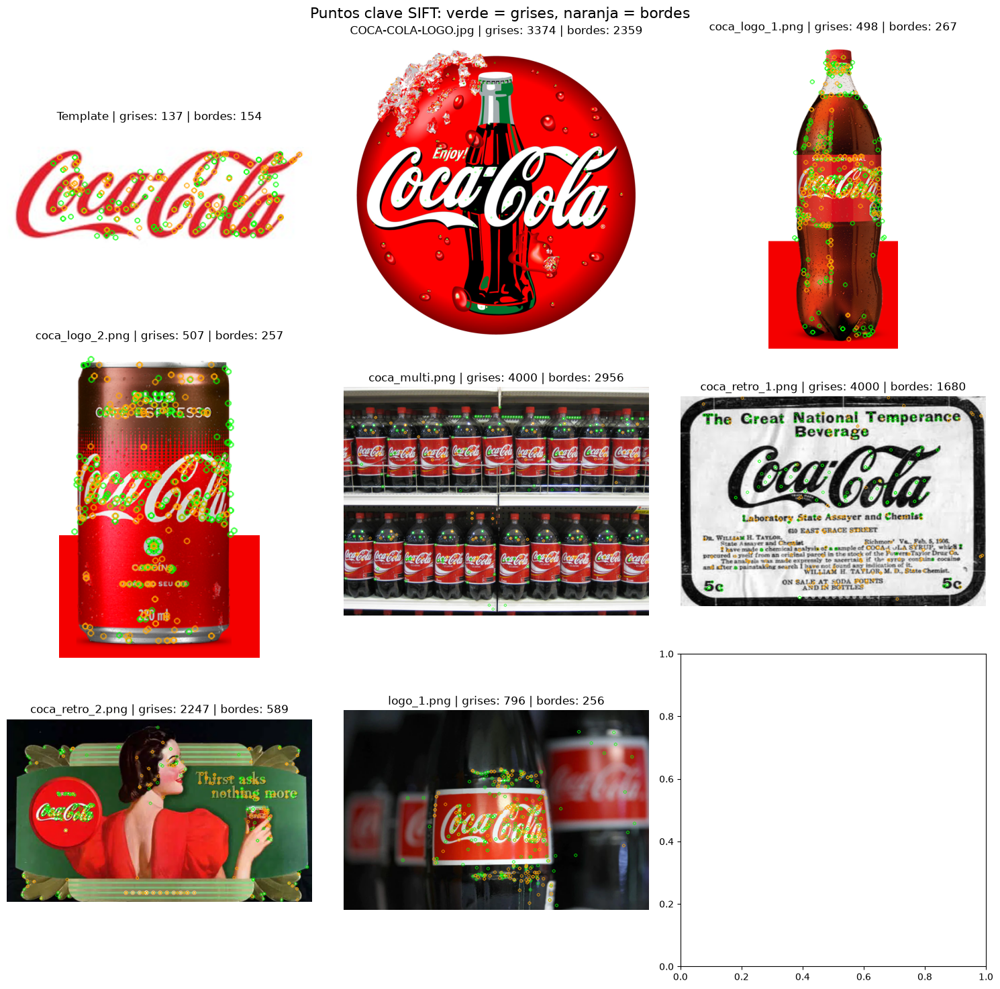

In [4]:
def obtener_puntos_clave_sift(imagen_gris, detector_sift):
    bordes = cv2.Canny(cv2.GaussianBlur(imagen_gris, (5, 5), 0), 50, 150)
    puntos_grises = detector_sift.detect(imagen_gris, None)
    puntos_bordes = detector_sift.detect(bordes, None)
    return puntos_grises, puntos_bordes


def puntos_mas_fuertes(puntos, maximo=250):
    return sorted(puntos, key=lambda punto: punto.response, reverse=True)[:maximo]


def dibujar_puntos_clave(imagen_color, puntos_grises, puntos_bordes):
    resultado = cv2.drawKeypoints(
        imagen_color, puntos_mas_fuertes(puntos_grises), None, color=(0, 255, 0)
    )
    return cv2.drawKeypoints(
        resultado, puntos_mas_fuertes(puntos_bordes), None, color=(0, 165, 255)
    )


detector_sift = cv2.SIFT_create(nfeatures=4000, contrastThreshold=0.01)
ruta_template = Path.cwd() / "template" / "pattern.png"
imagen_template = cv2.imread(str(ruta_template))
puntos_template_grises, puntos_template_bordes = obtener_puntos_clave_sift(
    cv2.cvtColor(imagen_template, cv2.COLOR_BGR2GRAY), detector_sift
)

rutas_imagenes = sorted(buscar_carpeta().glob("*"))
columnas = 3
filas = (len(rutas_imagenes) + 1 + columnas - 1) // columnas
fig, axes = plt.subplots(filas, columnas, figsize=(15, 5 * filas))
axes = axes.flat

eje_template = next(axes)
eje_template.imshow(cv2.cvtColor(dibujar_puntos_clave(imagen_template, puntos_template_grises, puntos_template_bordes), cv2.COLOR_BGR2RGB))
eje_template.set_title(f"Template | grises: {len(puntos_template_grises)} | bordes: {len(puntos_template_bordes)}")
eje_template.axis("off")
print(f"Template: grises={len(puntos_template_grises)}, bordes={len(puntos_template_bordes)}")

for eje, ruta_imagen in zip(axes, rutas_imagenes):
    imagen_color = cv2.imread(str(ruta_imagen))
    imagen_gris = cv2.cvtColor(imagen_color, cv2.COLOR_BGR2GRAY)
    puntos_grises, puntos_bordes = obtener_puntos_clave_sift(imagen_gris, detector_sift)
    resultado = dibujar_puntos_clave(imagen_color, puntos_grises, puntos_bordes)
    eje.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    eje.set_title(f"{ruta_imagen.name} | grises: {len(puntos_grises)} | bordes: {len(puntos_bordes)}")
    eje.axis("off")
    print(f"{ruta_imagen.name}: grises={len(puntos_grises)}, bordes={len(puntos_bordes)}")

for eje in axes:
    eje.axis("off")

fig.suptitle("Puntos clave SIFT: verde = grises, naranja = bordes", fontsize=16)
plt.tight_layout()
plt.show()

Como se puede observar, SIFT detecta puntos clave en todas la imagenes menos en COCA-COLA-LOGO.png con lo cual al ejecutarlo deberíamos tener matching en todas las demás imagenes de la carpeta.

Cargando imagenes de la carpeta: /Users/wasotelo/Estudios/Vision por computadora/Solución_TP_3/images


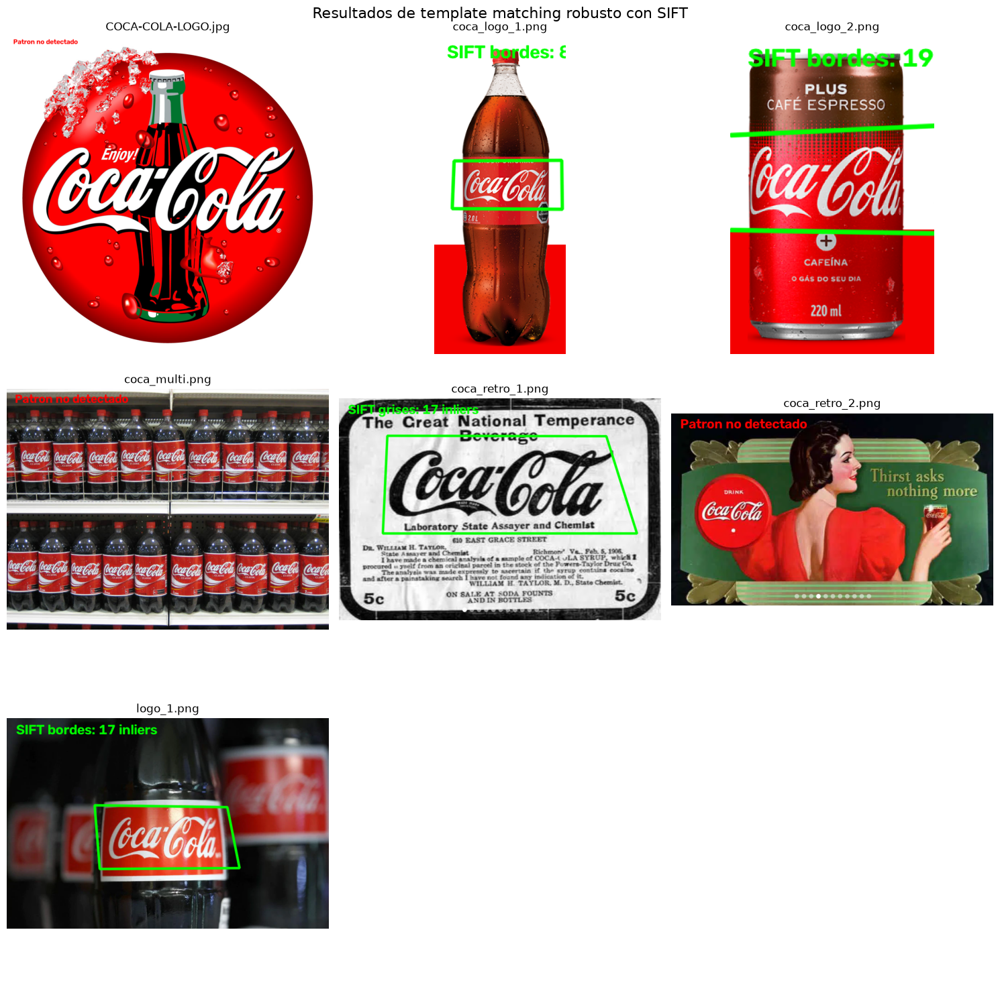

In [5]:
## Recorremos la carpeta imagenes/white_patch para leer cada imagen y pasarle al metodo
ruta_carpeta = buscar_carpeta()
print("Cargando imagenes de la carpeta: " + str(ruta_carpeta))

template_path = Path.cwd() / "template" / "pattern.png"
if not template_path.is_file():
    raise FileNotFoundError(f"No se pudo encontrar el patrón: {template_path}")

extensiones_imagen = {".jpg", ".jpeg", ".png"}
rutas_imagenes = sorted(
    (ruta for ruta in ruta_carpeta.iterdir() if ruta.suffix.lower() in extensiones_imagen),
    key=lambda ruta: ruta.name,
)
if not rutas_imagenes:
    raise FileNotFoundError(f"No se encontraron imágenes en {ruta_carpeta}")

columnas = 3
filas = (len(rutas_imagenes) + columnas - 1) // columnas
fig, axes = plt.subplots(filas, columnas, figsize=(15, 5 * filas))

for eje, ruta_imagen in zip(axes.flat, rutas_imagenes):
    resultado = detectar_objeto_sift_robusto(str(ruta_imagen), str(template_path))
    eje.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    eje.set_title(ruta_imagen.name)
    eje.axis("off")

for eje in axes.flat[len(rutas_imagenes):]:
    eje.axis("off")

fig.suptitle("Resultados de template matching robusto con SIFT", fontsize=16)
plt.tight_layout()
plt.show()
   

Vemos que hay match, menos en la que ya sabiamos que no se habían detectado puntos claves. Pero además en la que es multi clase y en la retro-2. 
En multi lo más razonable es que como el algoritmo no está pensando para detectar multiples instancias, no detecta suficientes puntos para cada logo.
El retro-2, si vemos si detecta multiple puntos, pero, como internamente usa escalado por piramides hasta cierto punto, puede ser que no llegue a detectarlo por que no llega con el escalado del template.

## Comparación SIFT con pirámide manual del template

SIFT reduce cada octava interna al 50%, por lo que ese porcentaje no se puede modificar desde OpenCV. Para probar reducciones adicionales del patrón, se construyen pirámides manuales del template a diferentes % de su tamaño original. Se mantiene el requisito de 8 inliers para no introducir falsos positivos.
Esto lo hacemos para probár o refutar la hipotesis de que SIFT no llega al escalado de pirámides por el tamaño del logo en la imagen.

Default: detección=False, máximo intento=(5, 'grises', 1.0)
Detalle default:
  template 100% | bordes: 4 coincidencias, 4 inliers
  template 100% | grises: 15 coincidencias, 5 inliers
  template 85% | bordes: 6 coincidencias, 4 inliers
  template 85% | grises: 5 coincidencias, 0 inliers
  template 70% | bordes: 7 coincidencias, 5 inliers
  template 70% | grises: 0 coincidencias, 0 inliers
  template 50% | bordes: 5 coincidencias, 0 inliers
  template 50% | grises: 0 coincidencias, 0 inliers
  template 30% | bordes: 2 coincidencias, 0 inliers
  template 30% | grises: 0 coincidencias, 0 inliers
  template 15% | bordes: 0 coincidencias, 0 inliers
  template 15% | grises: 0 coincidencias, 0 inliers
Pirámide: detección=False, máximo intento=(5, 'grises', 1.0)
Detalle pirámide:
  template 100% | bordes: 4 coincidencias, 4 inliers
  template 100% | grises: 15 coincidencias, 5 inliers
  template 85% | bordes: 6 coincidencias, 4 inliers
  template 85% | grises: 5 coincidencias, 0 inliers
  temp

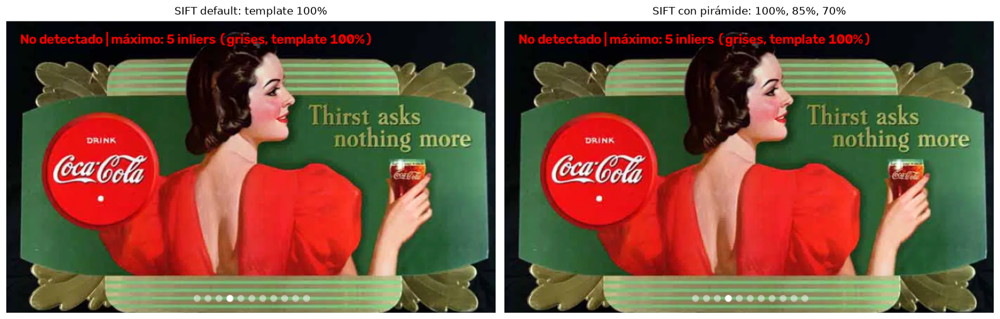

In [6]:
def detectar_objeto_sift_piramide_template(
    imagen_path, template_path, escalas_template=(1.0,), min_match_count=8
):
    imagen_escena = cv2.imread(str(imagen_path), cv2.IMREAD_GRAYSCALE)
    imagen_template = cv2.imread(str(template_path), cv2.IMREAD_GRAYSCALE)
    if imagen_escena is None or imagen_template is None:
        raise FileNotFoundError("No se pudo cargar la escena o el patrón.")

    sift = cv2.SIFT_create(nfeatures=4000, contrastThreshold=0.01)
    matcher = cv2.BFMatcher(cv2.NORM_L2)
    mejor_candidato = None
    mejor_intento = (0, None, None)
    diagnostico = []

    for escala_template in escalas_template:
        if not 0 < escala_template <= 1:
            raise ValueError("Las escalas del template deben estar entre 0 y 1.")

        template_escalado = cv2.resize(
            imagen_template, None, fx=escala_template, fy=escala_template, interpolation=cv2.INTER_AREA
        )
        alto_template, ancho_template = template_escalado.shape
        esquinas_template = np.float32(
            [[0, 0], [0, alto_template - 1], [ancho_template - 1, alto_template - 1], [ancho_template - 1, 0]]
        ).reshape(-1, 1, 2)
        variantes = {
            "bordes": (
                cv2.Canny(cv2.GaussianBlur(template_escalado, (5, 5), 0), 50, 150),
                cv2.Canny(cv2.GaussianBlur(imagen_escena, (5, 5), 0), 50, 150),
            ),
            "grises": (template_escalado, imagen_escena),
        }

        for nombre_variante, (template_procesado, escena_procesada) in variantes.items():
            puntos_template, descriptores_template = sift.detectAndCompute(template_procesado, None)
            puntos_escena, descriptores_escena = sift.detectAndCompute(escena_procesada, None)
            if descriptores_template is None or descriptores_escena is None:
                continue

            pares = matcher.knnMatch(descriptores_template, descriptores_escena, k=2)
            buenas_coincidencias = [
                primero for par in pares if len(par) == 2
                for primero, segundo in [par] if primero.distance < 0.75 * segundo.distance
            ]
            if len(buenas_coincidencias) < 4:
                diagnostico.append((escala_template, nombre_variante, len(buenas_coincidencias), 0))
                continue

            origen = np.float32([puntos_template[match.queryIdx].pt for match in buenas_coincidencias]).reshape(-1, 1, 2)
            destino = np.float32([puntos_escena[match.trainIdx].pt for match in buenas_coincidencias]).reshape(-1, 1, 2)
            homografia, mascara_inliers = cv2.findHomography(origen, destino, cv2.RANSAC, 5.0)
            cantidad_inliers = 0 if mascara_inliers is None else int(mascara_inliers.sum())
            diagnostico.append((escala_template, nombre_variante, len(buenas_coincidencias), cantidad_inliers))
            if cantidad_inliers > mejor_intento[0]:
                mejor_intento = (cantidad_inliers, nombre_variante, escala_template)
            if homografia is None or cantidad_inliers < min_match_count:
                continue

            esquinas_escena = cv2.perspectiveTransform(esquinas_template, homografia).reshape(-1, 2)
            area_relativa = cv2.contourArea(esquinas_escena) / imagen_escena.size
            longitudes_lados = np.linalg.norm(
                esquinas_escena - np.roll(esquinas_escena, -1, axis=0), axis=1
            )
            relacion_lados = longitudes_lados.min() / longitudes_lados.max()
            es_convexo = cv2.isContourConvex(np.int32(esquinas_escena))
            if not es_convexo or not 0.02 <= area_relativa <= 0.7 or relacion_lados < 0.25:
                continue

            candidato = (cantidad_inliers, nombre_variante, escala_template, esquinas_escena)
            if mejor_candidato is None or candidato[0] > mejor_candidato[0]:
                mejor_candidato = candidato

    resultado = cv2.imread(str(imagen_path))
    if mejor_candidato is None:
        inliers, variante, escala = mejor_intento
        etiqueta = f"No detectado | máximo: {inliers} inliers"
        if escala is not None:
            etiqueta += f" ({variante}, template {escala:.0%})"
        cv2.putText(resultado, etiqueta, (20, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 0, 255), 2)
        return resultado, None, mejor_intento, diagnostico

    cantidad_inliers, nombre_variante, escala_template, esquinas_escena = mejor_candidato
    cv2.polylines(resultado, [np.int32(esquinas_escena)], True, (0, 255, 0), 3, cv2.LINE_AA)
    etiqueta = f"SIFT {nombre_variante}: {cantidad_inliers} inliers | template {escala_template:.0%}"
    cv2.putText(resultado, etiqueta, (20, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 0), 2)
    return resultado, mejor_candidato, mejor_intento, diagnostico


ruta_retro_2 = buscar_carpeta() / "coca_retro_2.png"
ruta_template = Path.cwd() / "template" / "pattern.png"
resultado_default, deteccion_default, intento_default, diagnostico_default = detectar_objeto_sift_piramide_template(
    ruta_retro_2, ruta_template, escalas_template=(1.0,0.85, 0.70, 0.50, 0.30, 0.15)
)
resultado_piramide, deteccion_piramide, intento_piramide, diagnostico_piramide = detectar_objeto_sift_piramide_template(
    ruta_retro_2, ruta_template, escalas_template=(1.0, 0.85, 0.70, 0.50, 0.30, 0.15)
)

fig, ejes = plt.subplots(1, 2, figsize=(16, 6))
for eje, resultado, titulo in zip(
    ejes,
    (resultado_default, resultado_piramide),
    ("SIFT default: template 100%", "SIFT con pirámide: 100%, 85%, 70%"),
):
    eje.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    eje.set_title(titulo)
    eje.axis("off")

def imprimir_diagnostico(nombre, diagnostico):
    print(nombre)
    for escala, variante, coincidencias, inliers in diagnostico:
        print(f"  template {escala:.0%} | {variante}: {coincidencias} coincidencias, {inliers} inliers")


print(f"Default: detección={deteccion_default is not None}, máximo intento={intento_default}")
imprimir_diagnostico("Detalle default:", diagnostico_default)
print(f"Pirámide: detección={deteccion_piramide is not None}, máximo intento={intento_piramide}")
imprimir_diagnostico("Detalle pirámide:", diagnostico_piramide)
plt.tight_layout()
plt.show()

Observamos que el mejor resultado sigue siendo 5 inliners y reducir el template no mejora la detección, de hecho puede empeorarla con lo cual ésto refuta nuestra hipótesis.

## Ítem 2 — Detector multi-instancia para `coca_multi.png`

Busca todas las apariciones del logo con template matching multiescala y elimina cajas duplicadas con NMS.

In [7]:
def detectar_logos_multinstancia(imagen_path, template_path, escalas=None, umbral=0.42, proporcion_roja_minima=0.25):
    def mascara_roja(imagen):
        imagen_hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)
        rojo_bajo = cv2.inRange(imagen_hsv, (0, 90, 50), (10, 255, 255))
        rojo_alto = cv2.inRange(imagen_hsv, (170, 90, 50), (180, 255, 255))
        return cv2.bitwise_or(rojo_bajo, rojo_alto)

    def interseccion_sobre_union(caja_a, caja_b):
        ax, ay, ancho_a, alto_a = caja_a
        bx, by, ancho_b, alto_b = caja_b
        izquierda = max(ax, bx)
        superior = max(ay, by)
        derecha = min(ax + ancho_a, bx + ancho_b)
        inferior = min(ay + alto_a, by + alto_b)
        interseccion = max(0, derecha - izquierda) * max(0, inferior - superior)
        union = ancho_a * alto_a + ancho_b * alto_b - interseccion
        return interseccion / union if union else 0

    imagen = cv2.imread(str(imagen_path))
    template = cv2.imread(str(template_path))
    if imagen is None or template is None:
        raise FileNotFoundError("No se pudo cargar la escena o el patrón.")

    if escalas is None:
        escalas = np.geomspace(0.15, 3.0, 28)

    mascara_template = mascara_roja(template)
    imagen_hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)
    mascara_blanca = cv2.inRange(imagen_hsv, (0, 0, 150), (180, 110, 255))
    mascara_roja_escena = mascara_roja(imagen)
    candidatos = []

    for escala in escalas:
        ancho = round(mascara_template.shape[1] * escala)
        alto = round(mascara_template.shape[0] * escala)
        if ancho >= imagen.shape[1] or alto >= imagen.shape[0]:
            continue

        template_escalado = cv2.resize(mascara_template, (ancho, alto), interpolation=cv2.INTER_AREA)
        respuesta = cv2.matchTemplate(mascara_blanca, template_escalado, cv2.TM_CCOEFF_NORMED)
        maximos_locales = (respuesta >= umbral) & (
            respuesta == cv2.dilate(respuesta, np.ones((9, 9), np.uint8))
        )

        for y, x in zip(*np.where(maximos_locales)):
            caja = (int(x), int(y), ancho, alto)
            proporcion_roja = mascara_roja_escena[y:y + alto, x:x + ancho].mean() / 255
            if proporcion_roja >= proporcion_roja_minima:
                candidatos.append((float(respuesta[y, x]), caja))

    detecciones = []
    for puntaje, caja in sorted(candidatos, key=lambda candidato: candidato[0], reverse=True):
        if all(interseccion_sobre_union(caja, deteccion[1]) < 0.25 for deteccion in detecciones):
            detecciones.append((puntaje, caja))

    resultado = imagen.copy()
    for indice, (puntaje, (x, y, ancho, alto)) in enumerate(detecciones, start=1):
        cv2.rectangle(resultado, (x, y), (x + ancho, y + alto), (0, 255, 0), 2)
        cv2.putText(resultado, f"{indice}: {puntaje:.2f}", (x, max(18, y - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1, cv2.LINE_AA)

    return resultado, detecciones

### Diagnóstico de detecciones faltantes

Se compara el corte original de 0.45 contra 0.42 y se cuentan los candidatos descartados por el filtro de rojo y por NMS.

Umbral 0.45: {'máximos locales': 16, 'rechazados por rojo': 1, 'rechazados por NMS': 0, 'detecciones finales': 15, 'escalas con candidatos': [(np.float64(0.2337956592470603), 15)]}
Umbral 0.42: {'máximos locales': 113, 'rechazados por rojo': 91, 'rechazados por NMS': 5, 'detecciones finales': 17, 'escalas con candidatos': [(np.float64(0.20924261909436317), 1), (np.float64(0.2337956592470603), 17), (np.float64(0.26122981312003696), 4)]}


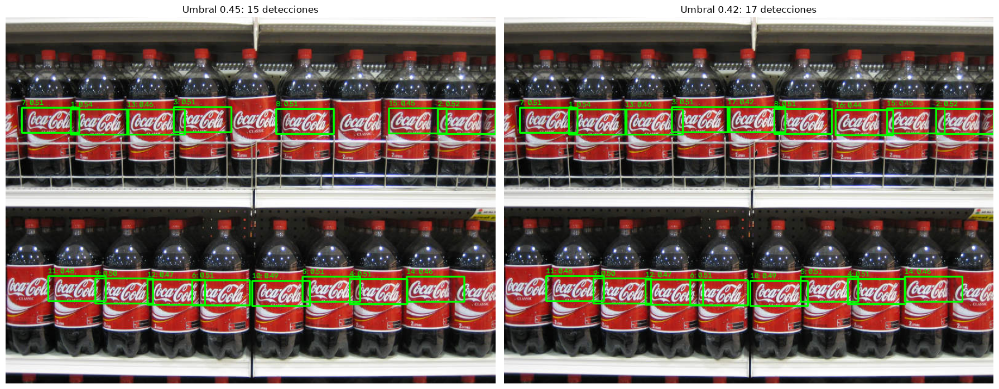

In [8]:
def diagnosticar_multinstancia(imagen_path, template_path, umbral, proporcion_roja_minima=0.25):
    def mascara_roja(imagen):
        imagen_hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)
        rojo_bajo = cv2.inRange(imagen_hsv, (0, 90, 50), (10, 255, 255))
        rojo_alto = cv2.inRange(imagen_hsv, (170, 90, 50), (180, 255, 255))
        return cv2.bitwise_or(rojo_bajo, rojo_alto)

    def interseccion_sobre_union(caja_a, caja_b):
        ax, ay, ancho_a, alto_a = caja_a
        bx, by, ancho_b, alto_b = caja_b
        izquierda = max(ax, bx)
        superior = max(ay, by)
        derecha = min(ax + ancho_a, bx + ancho_b)
        inferior = min(ay + alto_a, by + alto_b)
        interseccion = max(0, derecha - izquierda) * max(0, inferior - superior)
        union = ancho_a * alto_a + ancho_b * alto_b - interseccion
        return interseccion / union if union else 0

    imagen = cv2.imread(str(imagen_path))
    template = cv2.imread(str(template_path))
    mascara_template = mascara_roja(template)
    imagen_hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)
    mascara_blanca = cv2.inRange(imagen_hsv, (0, 0, 150), (180, 110, 255))
    mascara_roja_escena = mascara_roja(imagen)
    candidatos = []
    rechazados_rojo = 0
    maximos_locales = 0
    escalas_con_candidatos = []

    for escala in np.geomspace(0.15, 3.0, 28):
        ancho = round(mascara_template.shape[1] * escala)
        alto = round(mascara_template.shape[0] * escala)
        if ancho >= imagen.shape[1] or alto >= imagen.shape[0]:
            continue

        template_escalado = cv2.resize(mascara_template, (ancho, alto), interpolation=cv2.INTER_AREA)
        respuesta = cv2.matchTemplate(mascara_blanca, template_escalado, cv2.TM_CCOEFF_NORMED)
        maximos = (respuesta >= umbral) & (respuesta == cv2.dilate(respuesta, np.ones((9, 9), np.uint8)))
        encontrados_escala = 0

        for y, x in zip(*np.where(maximos)):
            maximos_locales += 1
            proporcion_roja = mascara_roja_escena[y:y + alto, x:x + ancho].mean() / 255
            if proporcion_roja < proporcion_roja_minima:
                rechazados_rojo += 1
                continue
            candidatos.append((float(respuesta[y, x]), (int(x), int(y), ancho, alto)))
            encontrados_escala += 1

        if encontrados_escala:
            escalas_con_candidatos.append((escala, encontrados_escala))

    detecciones = []
    rechazados_nms = 0
    for puntaje, caja in sorted(candidatos, key=lambda candidato: candidato[0], reverse=True):
        if all(interseccion_sobre_union(caja, deteccion[1]) < 0.25 for deteccion in detecciones):
            detecciones.append((puntaje, caja))
        else:
            rechazados_nms += 1

    return {
        "máximos locales": maximos_locales,
        "rechazados por rojo": rechazados_rojo,
        "rechazados por NMS": rechazados_nms,
        "detecciones finales": len(detecciones),
        "escalas con candidatos": escalas_con_candidatos,
    }


ruta_multi = buscar_carpeta() / "coca_multi.png"
ruta_template = Path.cwd() / "template" / "pattern.png"
umbrales = (0.45, 0.42)
resultados = []

for umbral in umbrales:
    diagnostico = diagnosticar_multinstancia(ruta_multi, ruta_template, umbral)
    resultado, detecciones = detectar_logos_multinstancia(ruta_multi, ruta_template, umbral=umbral)
    resultados.append((umbral, resultado, detecciones))
    print(f"Umbral {umbral:.2f}: {diagnostico}")

fig, ejes = plt.subplots(1, 2, figsize=(18, 7))
for eje, (umbral, resultado, detecciones) in zip(ejes, resultados):
    eje.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    eje.set_title(f"Umbral {umbral:.2f}: {len(detecciones)} detecciones")
    eje.axis("off")

plt.tight_layout()
plt.show()

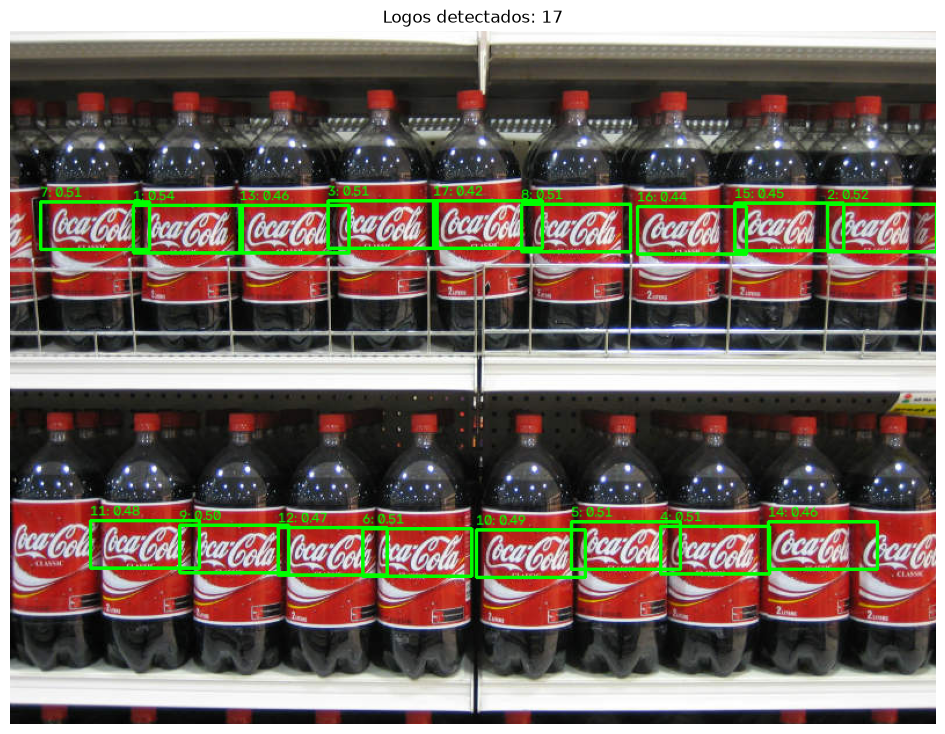

In [9]:
ruta_multi = buscar_carpeta() / "coca_multi.png"
ruta_template = Path.cwd() / "template" / "pattern.png"
resultado_multi, detecciones_multi = detectar_logos_multinstancia(ruta_multi, ruta_template)

plt.figure(figsize=(14, 9))
plt.imshow(cv2.cvtColor(resultado_multi, cv2.COLOR_BGR2RGB))
plt.title(f"Logos detectados: {len(detecciones_multi)}")
plt.axis("off")
plt.show()

Se detectaron 17 logos sin falsos positivos,  mientras que el requisito mínimo era detactar 5 logos con lo cual el algoritmo es exitoso en la detección.

## Ítem 1 — Una detección por imagen

Implementamos un algorítmo híbrido para intentar cubrir todos los casos (multiples logos, patrones superpuestos al logo). Primero se intenta detectar el objeto mediante SIFT. Si la homografía obtenida con RANSAC no es válida o no reúne la cantidad mínima de inliers requerida, se aplica el algoritmo de template matching multiescala calculada por el mismo algoritmo.

In [10]:
def detectar_template_multiescala(imagen_path, template_path, umbral=0.5):
    def mascara_roja(imagen):
        imagen_hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)
        rojo_bajo = cv2.inRange(imagen_hsv, (0, 90, 50), (10, 255, 255))
        rojo_alto = cv2.inRange(imagen_hsv, (170, 90, 50), (180, 255, 255))
        return cv2.bitwise_or(rojo_bajo, rojo_alto)

    imagen = cv2.imread(str(imagen_path))
    template = cv2.imread(str(template_path))
    if imagen is None or template is None:
        raise FileNotFoundError("No se pudo cargar la escena o el patrón.")

    mascara_template = mascara_roja(template)
    imagen_hsv = cv2.cvtColor(imagen, cv2.COLOR_BGR2HSV)
    mascara_blanca = cv2.inRange(imagen_hsv, (0, 0, 150), (180, 110, 255))
    mascara_roja_escena = mascara_roja(imagen)
    mejor_coincidencia = None

    for escala in np.geomspace(0.15, 3.0, 28):
        ancho = round(mascara_template.shape[1] * escala)
        alto = round(mascara_template.shape[0] * escala)
        if ancho >= imagen.shape[1] or alto >= imagen.shape[0]:
            continue

        template_escalado = cv2.resize(mascara_template, (ancho, alto), interpolation=cv2.INTER_AREA)
        respuesta = cv2.matchTemplate(mascara_blanca, template_escalado, cv2.TM_CCOEFF_NORMED)
        _, puntaje, _, ubicacion = cv2.minMaxLoc(respuesta)
        x, y = ubicacion
        proporcion_roja = mascara_roja_escena[y:y + alto, x:x + ancho].mean() / 255
        if proporcion_roja >= 0.25 and (mejor_coincidencia is None or puntaje > mejor_coincidencia[0]):
            mejor_coincidencia = (puntaje, (x, y, ancho, alto))

    resultado = imagen.copy()
    if mejor_coincidencia is None or mejor_coincidencia[0] < umbral:
        return resultado, None

    puntaje, (x, y, ancho, alto) = mejor_coincidencia
    cv2.rectangle(resultado, (x, y), (x + ancho, y + alto), (255, 0, 0), 3)
    cv2.putText(resultado, f"Template: {puntaje:.2f}", (x, max(25, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    return resultado, mejor_coincidencia


def detectar_objeto_hibrido(imagen_path, template_path):
    resultado_sift, deteccion_sift = detectar_objeto_sift_robusto(
        imagen_path, template_path, devolver_deteccion=True
    )
    if deteccion_sift is not None:
        return resultado_sift, "SIFT"

    resultado_template, deteccion_template = detectar_template_multiescala(imagen_path, template_path)
    if deteccion_template is not None:
        return resultado_template, "Template Matching"

    return resultado_sift, "Sin detección"

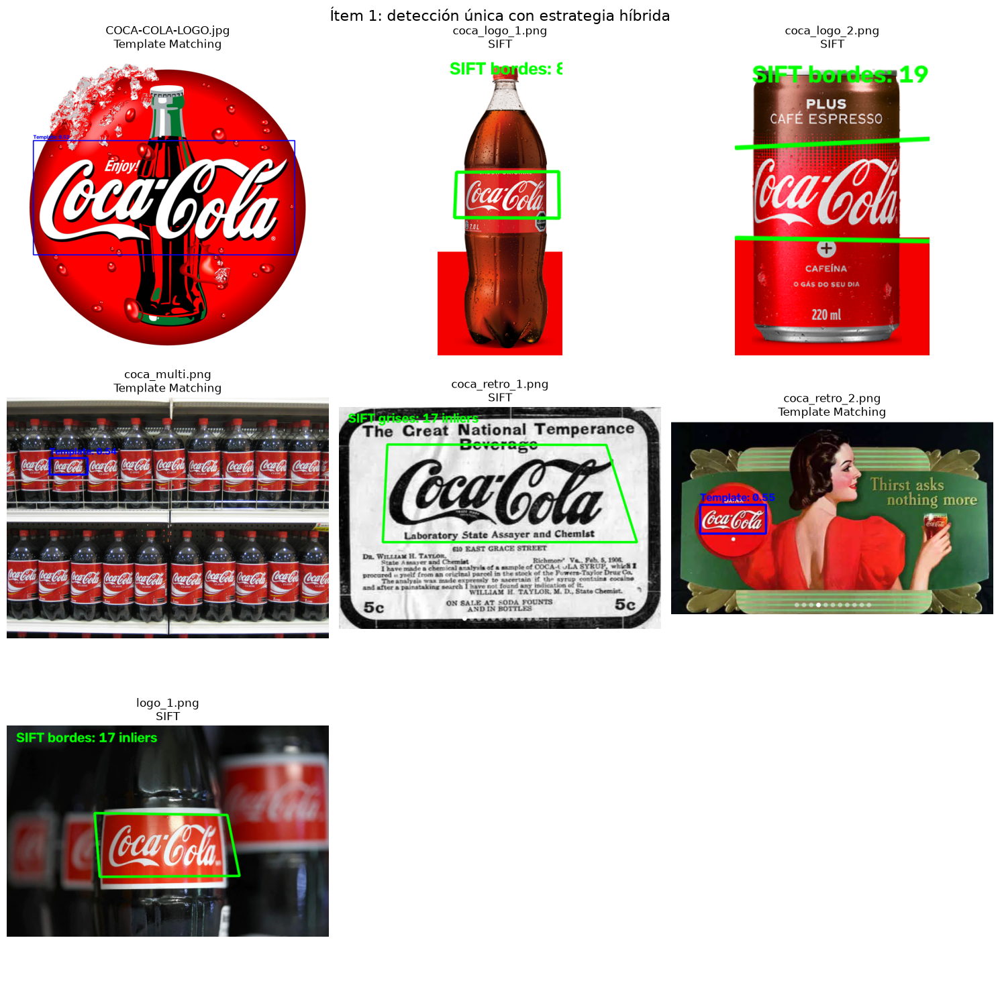

In [11]:
ruta_template = Path.cwd() / "template" / "pattern.png"
rutas_escena = sorted(buscar_carpeta().glob("*"))
columnas = 3
filas = (len(rutas_escena) + columnas - 1) // columnas
fig, axes = plt.subplots(filas, columnas, figsize=(15, 5 * filas))

for eje, ruta_escena in zip(axes.flat, rutas_escena):
    resultado, metodo = detectar_objeto_hibrido(ruta_escena, ruta_template)

    eje.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    eje.set_title(f"{ruta_escena.name}\n{metodo}")
    eje.axis("off")

for eje in axes.flat[len(rutas_escena):]:
    eje.axis("off")

fig.suptitle("Ítem 1: detección única con estrategia híbrida", fontsize=16)
plt.tight_layout()
plt.show()

SIFT falla en COCA-COLA-LOGO.png posiblemente por la presencia de la botella que atraviesa al logo y las gotas, generando muchos keypoints no correspondidos (casi 6000 en total). También falla en multi por la presencia de multiples instancias del logo como se describió anteriormente (algoritmo no apropiado para éste tipo de imágen). Por último falla en coca_retro_2 no por una cuestión de escala, sinó que posiblemente muchos de los keypoints encontrados en la imágen están fuera del logo.

En los 3 casos donde la pasada con SIFT no logró una detección exitosa, template matching sí lo hizo. Además, en ninguna imágen hubieron falsos positivos. Con lo cual, el algoritmo propuesto detecta el logo en todas las imágenes.

## Ítem 3 — Generalización para todas las imágenes

El algoritmo prioriza SIFT para obtener una detección geométricamente validada. Si no hay homografía, generaliza el template matching multi-instancia con un rango de escalas más amplio y NMS.

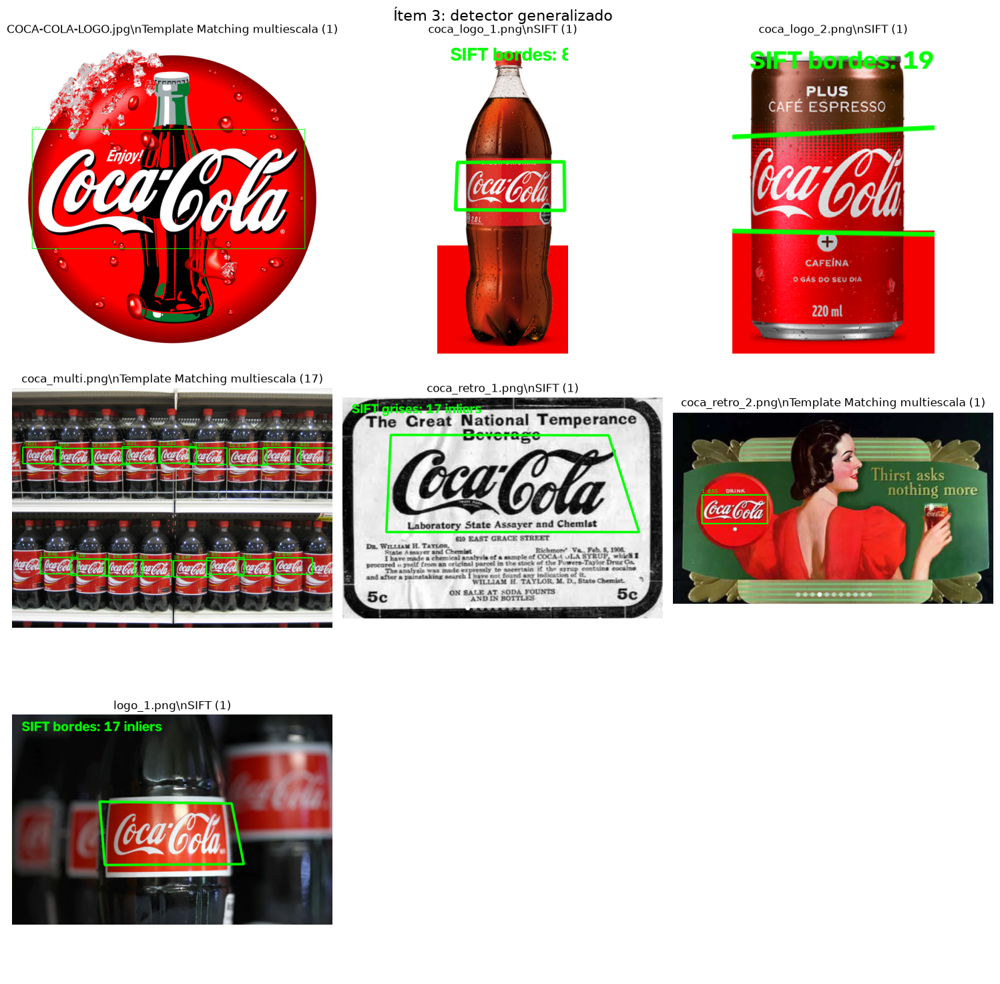

In [12]:
def detectar_logos_generalizado(imagen_path, template_path):
    resultado_sift, deteccion_sift = detectar_objeto_sift_robusto(
        imagen_path, template_path, devolver_deteccion=True
    )
    if deteccion_sift is not None:
        return resultado_sift, [deteccion_sift], "SIFT (1)"

    escalas_generalizadas = np.geomspace(0.15, 3.0, 28)
    resultado_multi, detecciones_multi = detectar_logos_multinstancia(
        imagen_path, template_path, escalas=escalas_generalizadas
    )
    if detecciones_multi:
        return resultado_multi, detecciones_multi, f"Template Matching multiescala ({len(detecciones_multi)})"

    resultado_template, deteccion_template = detectar_template_multiescala(
        imagen_path, template_path
    )
    if deteccion_template is not None:
        return resultado_template, [deteccion_template], "Template Matching (1)"

    return resultado_sift, [], "Sin detección"


ruta_template = Path.cwd() / "template" / "pattern.png"
extensiones_imagen = {".jpg", ".jpeg", ".png"}
rutas_escena = sorted(
    ruta for ruta in buscar_carpeta().glob("*") if ruta.suffix.lower() in extensiones_imagen
)
columnas = 3
filas = (len(rutas_escena) + columnas - 1) // columnas
fig, axes = plt.subplots(filas, columnas, figsize=(15, 5 * filas))

for eje, ruta_escena in zip(axes.flat, rutas_escena):
    resultado, detecciones, metodo = detectar_logos_generalizado(ruta_escena, ruta_template)
    eje.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    eje.set_title(f"{ruta_escena.name}\\n{metodo}")
    eje.axis("off")

for eje in axes.flat[len(rutas_escena):]:
    eje.axis("off")

fig.suptitle("Ítem 3: detector generalizado", fontsize=16)
plt.tight_layout()
plt.show()